In [9]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy.stats import ks_2samp

np.random.seed(42)
SPLIT_DIR      = Path("../data/processed/02_split")        # output từ notebook 02
PROCESSED_BASE = Path("../data/processed")              # file TTTH gốc
DIST_DIR       = Path("../data/processed/03_distribution")  # output từ notebook 03
PROCESSED_DIR = Path("../data/processed/04_synthetic")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

likert_cols = ['likert_nang_dong','likert_huong_noi','likert_sang_tao','likert_logic',
               'likert_to_mo','likert_thi_nghiem','likert_moi_truong',
               'likert_dinh_duong','likert_tranh_luan','likert_thiet_ke']

df_train_khaosat = pd.read_csv(SPLIT_DIR / "khaosat_train.csv")
df_ttth = pd.read_csv(PROCESSED_BASE / "TTTH_processed_flatten.csv")

with open(DIST_DIR / "phan_phoi_theo_nganh.json", encoding='utf-8') as f:
    phan_phoi_data = json.load(f)

phan_phoi = {int(k): v for k, v in phan_phoi_data['theo_nganh'].items()}
phan_phoi_global = phan_phoi_data['toan_cuc']

ten_to_ma = {
    "Quản trị dịch vụ du lịch và lữ hành": 7810103, "Quản trị khách sạn": 7810201,
    "Quản trị nhà hàng và dịch vụ ăn uống": 7810202, "Khoa học dinh dưỡng và ẩm thực": 7819009,
    "Khoa học chế biến món ăn": 7819010, "Du lịch": 7810101, "Luật": 7380101,
    "Luật kinh tế": 7380107, "Ngôn ngữ Anh": 7220201, "Ngôn ngữ Trung Quốc": 7220204,
    "Công nghệ thông tin": 7480201, "An toàn thông tin": 7480202, "Khoa học dữ liệu": 7460108,
    "Kế toán": 7340301, "Tài chính ngân hàng": 7340201, "Công nghệ tài chính": 7340205,
    "Marketing": 7340115, "Thương mại điện tử": 7340122,
    "Logistics và quản lý chuỗi cung ứng": 7510605, "Quản trị kinh doanh": 7340101,
    "Kinh doanh quốc tế": 7340120, "Công nghệ dệt, may": 7540204,
    "Kinh doanh thời trang và dệt may": 7340123, "Công nghệ thực phẩm": 7540101,
    "Đảm bảo chất lượng và an toàn thực phẩm": 7540106, "Quản trị kinh doanh thực phẩm": 7340129,
    "Công nghệ chế biến thủy sản": 7540105, "Công nghệ chế tạo máy": 7510202,
    "Công nghệ kỹ thuật cơ điện tử": 7510203, "Kỹ thuật nhiệt": 7520115,
    "Công nghệ kỹ thuật điện - điện tử": 7510301,
    "Công nghệ kỹ thuật điều khiển và TĐH": 7510303, "Công nghệ kỹ thuật hóa học": 7510401,
    "Công nghệ vật liệu": 7510402, "Công nghệ sinh học": 7420201,
    "Quản lý tài nguyên và môi trường": 7850101, "Công nghệ kỹ thuật môi trường": 7510406,
    "Trí tuệ nhân tạo": 7480107, "Quản lý Công nghiệp": 7510601,
}
df_train_khaosat['ma_nganh'] = df_train_khaosat['nganh_hoc'].map(ten_to_ma)

# Mã hóa mục tiêu (đã xác nhận đúng theo file gốc)
muc_tieu_ten_to_ma = {'Đi làm': 1, 'Nghiên cứu': 2, 'Kinh doanh': 3, 'Chưa xác định': 4}

# ============================================================
# ÁP SÀN STD — giữ nguyên
# ============================================================
SAN_STD = 0.4
for ma in phan_phoi:
    for c in likert_cols:
        phan_phoi[ma]['likert_std'][c] = max(phan_phoi[ma]['likert_std'][c], SAN_STD)
for c in likert_cols:
    phan_phoi_global['likert_std'][c] = max(phan_phoi_global['likert_std'][c], SAN_STD)


# ============================================================
# HÀM LÕI — GENETIC ALGORITHM (ĐÃ FIX)
# ============================================================
def lay_quan_the_that(ma_nganh, df_train_khaosat):
    sub = df_train_khaosat[df_train_khaosat['ma_nganh'] == ma_nganh]
    if len(sub) == 0:
        return None
    return sub[likert_cols].values


# FIX 1 — Đổi sang uniform_crossover (không co hẹp phương sai)
# arithmetic_crossover cũ: con = alpha*cha + (1-alpha)*me → thu hẹp phân phối sau nhiều thế hệ
# uniform_crossover mới:   mỗi gene được chọn ngẫu nhiên từ cha HOẶC mẹ → giữ nguyên phương sai
def uniform_crossover(cha, me, prob=0.5):
    mask = np.random.rand(len(cha)) < prob
    return np.where(mask, cha, me).astype(float)


# FIX 2 — Tăng he_so_muta 0.3→1.0 và ty_le_dot_bien 0.3→0.5
# Đột biến mạnh hơn để quần thể khám phá đủ rộng
def gaussian_mutation(individual, target_std, ty_le_dot_bien=0.5, he_so_muta=1.0):
    con = individual.copy()
    for i in range(len(con)):
        if np.random.rand() < ty_le_dot_bien:
            con[i] += np.random.normal(0, target_std[i] * he_so_muta)
    return np.clip(con, 1, 5)


def tournament_selection(quan_the, fitness_scores, k=3):
    idx = np.random.choice(len(quan_the), k, replace=False)
    best_idx = idx[np.argmax(fitness_scores[idx])]
    return quan_the[best_idx]


# FIX 3 — fitness_quan_the: phạt lệch mean + std của toàn quần thể
# Fitness cũ chỉ phạt từng cá thể riêng lẻ → không điều chỉnh được phân phối tổng thể
# Fitness mới thêm shared penalty: phạt khi mean/std của cả quần thể lệch khỏi mục tiêu
def fitness_quan_the(quan_the, target_mean, target_std):
    # Score cá nhân: cá thể nằm trong vùng hợp lý (±1.5 std so với mean mục tiêu)
    scores_ca_nhan = np.array([
        -np.sum(np.maximum(0, np.abs(ind - target_mean) / target_std - 1.5))
        for ind in quan_the
    ])

    # Shared penalty: phạt khi MEAN quần thể lệch (trọng số cao hơn)
    mean_qt = quan_the.mean(axis=0)
    phat_mean = np.sum(np.abs(mean_qt - target_mean) / target_std)

    # Shared penalty: phạt khi STD quần thể nhỏ hơn mục tiêu
    std_qt = quan_the.std(axis=0) + 1e-8
    phat_std = np.sum(np.maximum(0, target_std - std_qt) / target_std)  # chỉ phạt khi std QUÁ NHỎ

    # Áp dụng đều cho toàn quần thể
    scores = scores_ca_nhan - 3.0 * phat_mean - 2.0 * phat_std
    return scores


# FIX 5 — Rescale sau GA làm lưới an toàn cuối
# Đảm bảo mean và std của output khớp đúng mục tiêu, đặc biệt cho ngành cỡ mẫu nhỏ
def rescale_ve_muc_tieu(arr_sinh, target_mean, target_std):
    result = arr_sinh.astype(float).copy()
    for i in range(result.shape[1]):
        col = result[:, i]
        m, s = col.mean(), col.std()
        if s < 1e-6:
            # Degenerate case: std = 0, điền bằng phân phối Gaussian theo mục tiêu
            result[:, i] = np.random.normal(target_mean[i], target_std[i], size=len(col))
        else:
            result[:, i] = target_mean[i] + (col - m) * (target_std[i] / s)
    result = np.clip(result, 1, 5)
    return np.round(result).astype(int)


# FIX 4 — Giảm so_the_he 20→10, tăng kich_thuoc_quan_the 30→50
# Với uniform_crossover không cần nhiều thế hệ; quần thể lớn hơn → đa dạng hơn ngay từ đầu
def chay_ga_sinh_likert(ma_nganh, so_luong_can_sinh, so_the_he=10, kich_thuoc_quan_the=50):
    d = phan_phoi.get(ma_nganh, phan_phoi_global)
    target_mean = np.array([d['likert_mean'][c] for c in likert_cols])
    target_std  = np.array([d['likert_std'][c]  for c in likert_cols])

    quan_the_that = lay_quan_the_that(ma_nganh, df_train_khaosat)
    if quan_the_that is None or len(quan_the_that) == 0:
        quan_the = np.random.normal(target_mean, target_std, size=(kich_thuoc_quan_the, 10))
    else:
        idx = np.random.choice(len(quan_the_that), kich_thuoc_quan_the, replace=True)
        quan_the = quan_the_that[idx] + np.random.normal(0, 0.5, size=(kich_thuoc_quan_the, 10))
    quan_the = np.clip(quan_the, 1, 5)

    for the_he in range(so_the_he):
        scores = fitness_quan_the(quan_the, target_mean, target_std)
        quan_the_moi = []
        for _ in range(kich_thuoc_quan_the):
            cha = tournament_selection(quan_the, scores)
            me  = tournament_selection(quan_the, scores)
            con = uniform_crossover(cha, me)        # FIX 1
            con = gaussian_mutation(con, target_std) # FIX 2
            quan_the_moi.append(con)
        quan_the = np.array(quan_the_moi)

    idx_final = np.random.choice(len(quan_the), so_luong_can_sinh, replace=True)
    ket_qua = quan_the[idx_final]

    # FIX 5: rescale trước khi round
    ket_qua = rescale_ve_muc_tieu(ket_qua, target_mean, target_std)
    return ket_qua


def sinh_gioi_tinh(ma_nganh, n):
    p = phan_phoi.get(ma_nganh, phan_phoi_global)['gioi_tinh_ty_le_nam']
    return np.where(np.random.rand(n) < p, 'Nam', 'Nu')

def sinh_muc_tieu(ma_nganh, n):
    d = phan_phoi.get(ma_nganh, phan_phoi_global)['muc_tieu_phan_phoi']
    if not d:
        d = phan_phoi_global['muc_tieu_phan_phoi']
    return np.random.choice(list(d.keys()), size=n, p=list(d.values()))


# ============================================================
# GIAI ĐOẠN 4A — Bổ sung 12 cột cho TTTH
# ============================================================
print("=== 4A: Bổ sung likert/giới tính/mục tiêu cho TTTH ===")
ket_qua_ttth = []

for ma_nganh, group in df_ttth.groupby('ma_nganh'):
    n = len(group)
    likert_sinh = chay_ga_sinh_likert(ma_nganh, n)
    gioi_tinh_sinh = sinh_gioi_tinh(ma_nganh, n)
    muc_tieu_sinh  = sinh_muc_tieu(ma_nganh, n)

    group = group.copy()
    for i, c in enumerate(likert_cols):
        group[c] = likert_sinh[:, i]
    group['gioi_tinh']    = gioi_tinh_sinh
    group['muc_tieu_nhan'] = muc_tieu_sinh
    group['muc_tieu_ma']   = pd.Series(muc_tieu_sinh).map(muc_tieu_ten_to_ma).values
    group['nguon_du_lieu'] = 'ttth_bo_sung'
    group['sample_weight'] = 1
    ket_qua_ttth.append(group)

df_ttth_day_du = pd.concat(ket_qua_ttth, ignore_index=True)
print(f"Đã bổ sung xong {len(df_ttth_day_du)} dòng TTTH")


# ============================================================
# GIAI ĐOẠN 4B — Cân bằng lớp
# ============================================================
MUC_TIEU_MOI_NGANH = 80

print("\n=== 4B: Cân bằng lớp ===")
so_dong_ttth    = df_ttth_day_du['ma_nganh'].value_counts()
so_dong_khaosat = df_train_khaosat['ma_nganh'].value_counts()

ket_qua_can_bang = []

for ma_nganh in phan_phoi.keys():
    hien_co = so_dong_ttth.get(ma_nganh, 0) + so_dong_khaosat.get(ma_nganh, 0)
    can_sinh_them = max(0, MUC_TIEU_MOI_NGANH - hien_co)
    if can_sinh_them == 0:
        continue

    likert_sinh    = chay_ga_sinh_likert(ma_nganh, can_sinh_them)
    gioi_tinh_sinh = sinh_gioi_tinh(ma_nganh, can_sinh_them)
    muc_tieu_sinh  = sinh_muc_tieu(ma_nganh, can_sinh_them)

    nguon_diem = df_ttth[df_ttth['ma_nganh'] == ma_nganh]
    tu_khao_sat = False
    if len(nguon_diem) == 0:
        nguon_diem = df_train_khaosat[df_train_khaosat['ma_nganh'] == ma_nganh]
        tu_khao_sat = True

    idx_bootstrap = np.random.choice(len(nguon_diem), can_sinh_them, replace=True)
    dong_moi = nguon_diem.iloc[idx_bootstrap].copy().reset_index(drop=True)

    for i, c in enumerate(likert_cols):
        dong_moi[c] = likert_sinh[:, i]
    dong_moi['gioi_tinh']    = gioi_tinh_sinh
    dong_moi['muc_tieu_nhan'] = muc_tieu_sinh
    dong_moi['muc_tieu_ma']   = pd.Series(muc_tieu_sinh).map(muc_tieu_ten_to_ma).values
    dong_moi['ma_nganh']      = ma_nganh
    dong_moi['nguon_du_lieu'] = 'ga_can_bang_lop'
    dong_moi['sample_weight'] = 1

    ket_qua_can_bang.append(dong_moi)

df_can_bang = pd.concat(ket_qua_can_bang, ignore_index=True) if ket_qua_can_bang else pd.DataFrame()
print(f"Đã sinh thêm {len(df_can_bang)} dòng cân bằng lớp")

df_ttth_day_du.to_csv(PROCESSED_DIR / "ttth_day_du_12cot.csv", index=False, encoding='utf-8-sig')
df_can_bang.to_csv(PROCESSED_DIR / "ga_can_bang_lop.csv", index=False, encoding='utf-8-sig')
print("\n✅ Đã lưu 2 file, sẵn sàng cho Giai đoạn 5 (Gộp)")


=== 4A: Bổ sung likert/giới tính/mục tiêu cho TTTH ===
Đã bổ sung xong 15888 dòng TTTH

=== 4B: Cân bằng lớp ===
Đã sinh thêm 436 dòng cân bằng lớp

✅ Đã lưu 2 file, sẵn sàng cho Giai đoạn 5 (Gộp)


In [10]:
# ============================================================
# KIỂM ĐỊNH SAU FIX — Tiêu chí kép: Mean/Std + KS-statistic
# ============================================================
print("=== KIỂM ĐỊNH SAU FIX (Tiêu chí kép) ===\n")

NGUONG_MEAN_LECH   = 0.3   # điểm trên thang 1-5
NGUONG_STD_LECH_PCT = 0.30  # 30% so với std thật
NGUONG_KS_STAT     = 0.15   # không phụ thuộc cỡ mẫu

ket_qua = []
for ma_nganh in sorted(df_train_khaosat['ma_nganh'].dropna().unique()):
    that = df_train_khaosat[df_train_khaosat['ma_nganh'] == ma_nganh]
    ga   = df_ttth_day_du[df_ttth_day_du['ma_nganh'] == ma_nganh]
    if len(that) < 2 or len(ga) < 2:
        continue

    max_mean_lech = 0
    max_std_lech_pct = 0
    max_ks_stat = 0
    so_cot_lech_pvalue = 0

    for c in likert_cols:
        m_lech = abs(that[c].mean() - ga[c].mean())
        s_that = that[c].std()
        s_lech_pct = abs(s_that - ga[c].std()) / (s_that + 1e-8)
        ks_stat, p = ks_2samp(that[c].values, ga[c].values)

        max_mean_lech    = max(max_mean_lech, m_lech)
        max_std_lech_pct = max(max_std_lech_pct, s_lech_pct)
        max_ks_stat      = max(max_ks_stat, ks_stat)
        if p < 0.05:
            so_cot_lech_pvalue += 1

    dat_mean = max_mean_lech   <= NGUONG_MEAN_LECH
    dat_std  = max_std_lech_pct <= NGUONG_STD_LECH_PCT
    dat_ks   = max_ks_stat      <= NGUONG_KS_STAT
    dat_ca_3 = dat_mean and dat_std and dat_ks

    ket_qua.append({
        'ma_nganh': int(ma_nganh),
        'n_that': len(that), 'n_ga': len(ga),
        'max_mean_lech': round(max_mean_lech, 3),
        'max_std_lech_pct': round(max_std_lech_pct, 3),
        'max_ks_stat': round(max_ks_stat, 3),
        'so_cot_lech_p': so_cot_lech_pvalue,
        'dat_ca_3': dat_ca_3,
    })

df_kq = pd.DataFrame(ket_qua).sort_values('dat_ca_3')
print(df_kq.to_string(index=False))

n_dat  = df_kq['dat_ca_3'].sum()
n_tong = len(df_kq)
print(f"\n✅ Ngành đạt cả 3 tiêu chí: {n_dat} / {n_tong}  ({100*n_dat/n_tong:.0f}%)")
print(f"   (Tiêu chí: mean lệch ≤{NGUONG_MEAN_LECH} | std lệch ≤{NGUONG_STD_LECH_PCT*100:.0f}% | KS-stat ≤{NGUONG_KS_STAT})")

# Bảng tóm tắt mean/std cho 3 ngành đại diện
print("\n=== CHI TIẾT MEAN/STD: 3 NGÀNH ĐẠI DIỆN ===\n")
nganh_dai_dien = [7480201, 7340301, 7819009]
for ma_nganh in nganh_dai_dien:
    that = df_train_khaosat[df_train_khaosat['ma_nganh'] == ma_nganh]
    ga   = df_ttth_day_du[df_ttth_day_du['ma_nganh'] == ma_nganh]
    print(f"--- Ngành {ma_nganh} (that={len(that)}, ga={len(ga)}) ---")
    for c in likert_cols:
        m_that, s_that = that[c].mean(), that[c].std()
        m_ga, s_ga     = ga[c].mean(), ga[c].std()
        ok_m = "✅" if abs(m_that-m_ga) <= NGUONG_MEAN_LECH else "❌"
        ok_s = "✅" if abs(s_that-s_ga)/(s_that+1e-8) <= NGUONG_STD_LECH_PCT else "❌"
        print(f"  {c:20s}: {ok_m} Mean thật={m_that:.2f} GA={m_ga:.2f} (lệch {abs(m_that-m_ga):.2f})"
              f"  |  {ok_s} Std thật={s_that:.2f} GA={s_ga:.2f} (lệch {abs(s_that-s_ga):.2f})")
    print()


=== KIỂM ĐỊNH SAU FIX (Tiêu chí kép) ===

 ma_nganh  n_that  n_ga  max_mean_lech  max_std_lech_pct  max_ks_stat  so_cot_lech_p  dat_ca_3
  7220201      22   606          0.337             0.126        0.152              0     False
  7819009      10    91          0.104             0.118        0.207              0     False
  7810202      14   425          0.159             0.061        0.165              0     False
  7810201      12   488          0.172             0.089        0.212              0     False
  7810103      23   344          0.150             0.196        0.261              0     False
  7540204      18   270          0.241             0.190        0.222              0     False
  7540106       9   291          0.198             0.309        0.222              0     False
  7540105       7    77          0.299             0.247        0.338              0     False
  7540101      42   948          0.104             0.163        0.155              0     False
  752011

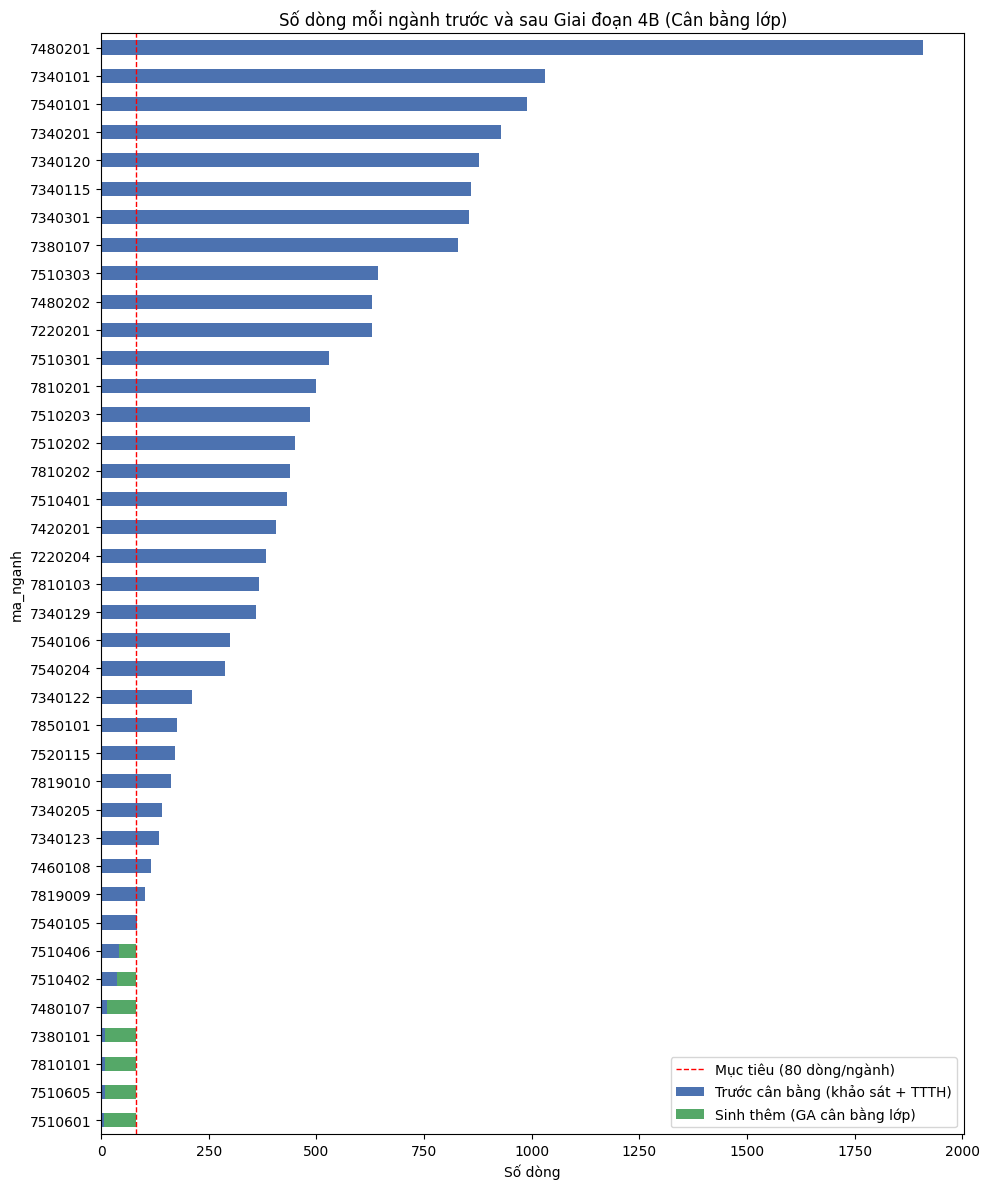

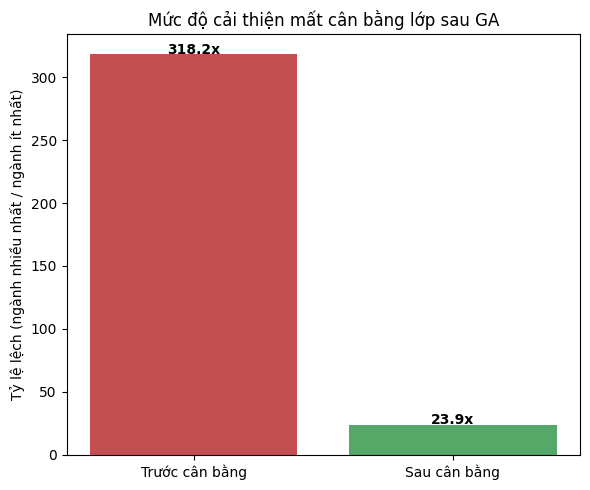

Tỷ lệ lệch trước cân bằng: 318.2 lần
Tỷ lệ lệch sau cân bằng: 23.9 lần

=== KIỂM ĐỊNH KS THEO TỪNG NGÀNH (không gộp, tránh lỗi trộn tỷ trọng) ===

 ma_nganh  so_mau_that  so_mau_ga  so_cot_lech  tong_cot
  7220201           22        606            0        10
  7540105            7         77            0        10
  7510303           18        626            0        10
  7510401           23        409            0        10
  7510402           18         19            0        10
  7510406            5         36            0        10
  7520115           16        155            0        10
  7540101           42        948            0        10
  7540106            9        291            0        10
  7220204           17        365            0        10
  7540204           18        270            0        10
  7810103           23        344            0        10
  7810201           12        488            0        10
  7810202           14        425            0        1

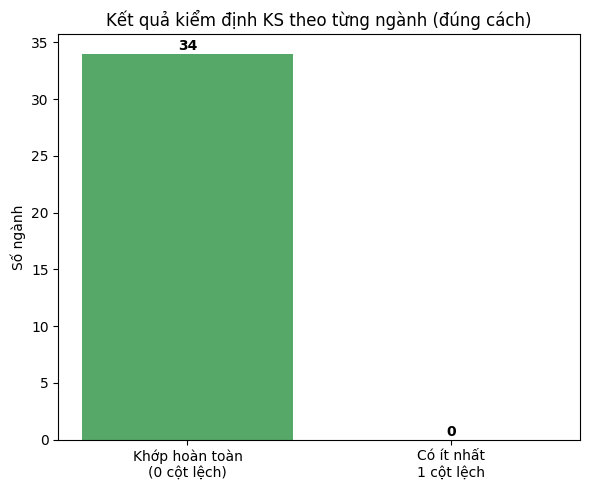

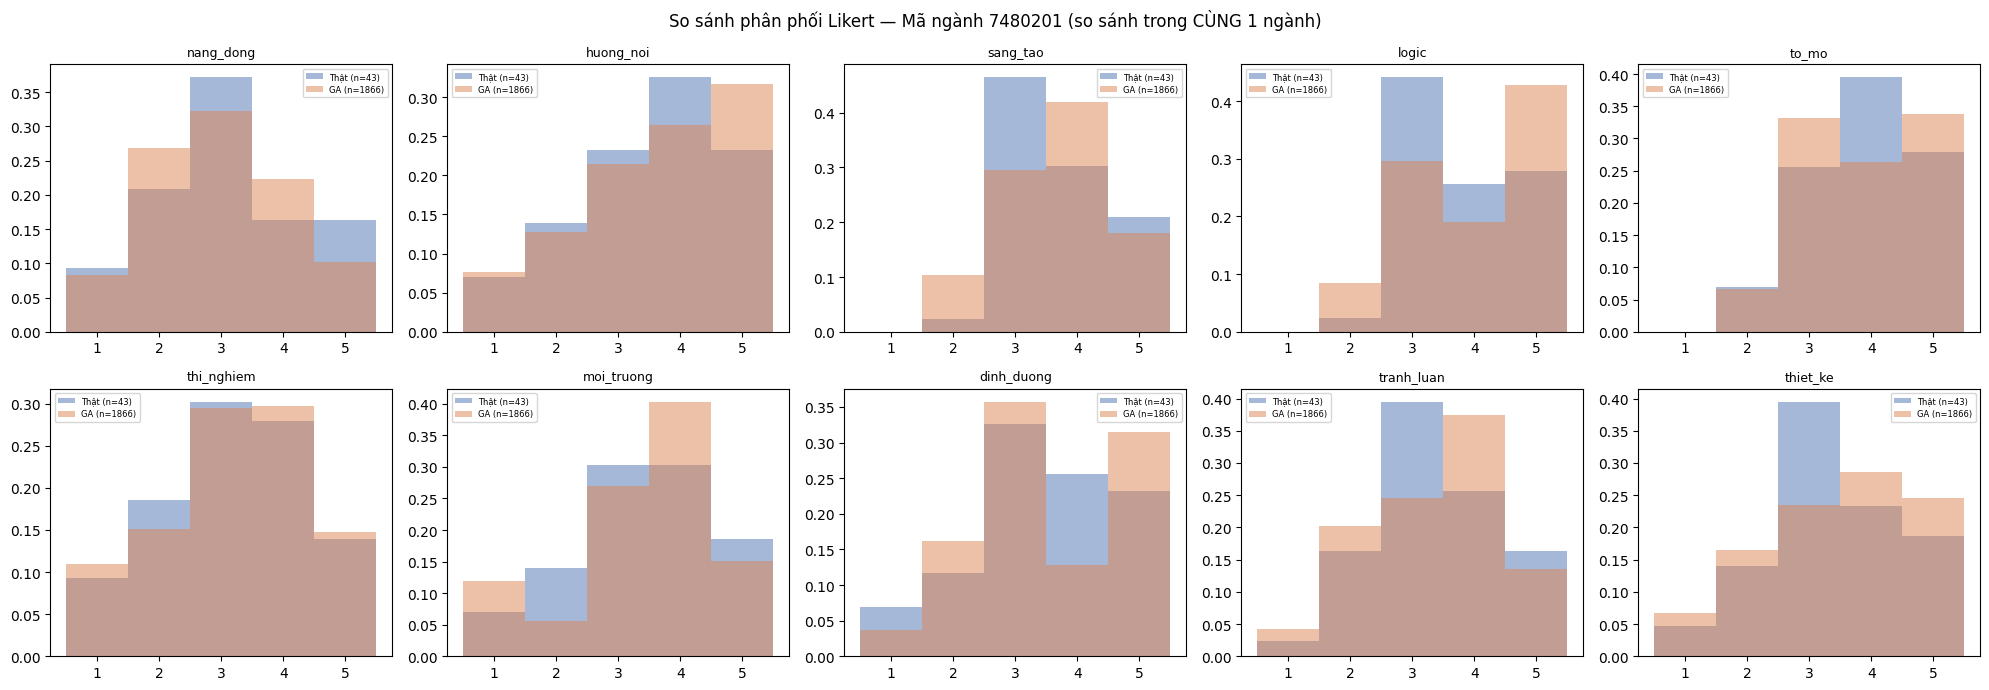

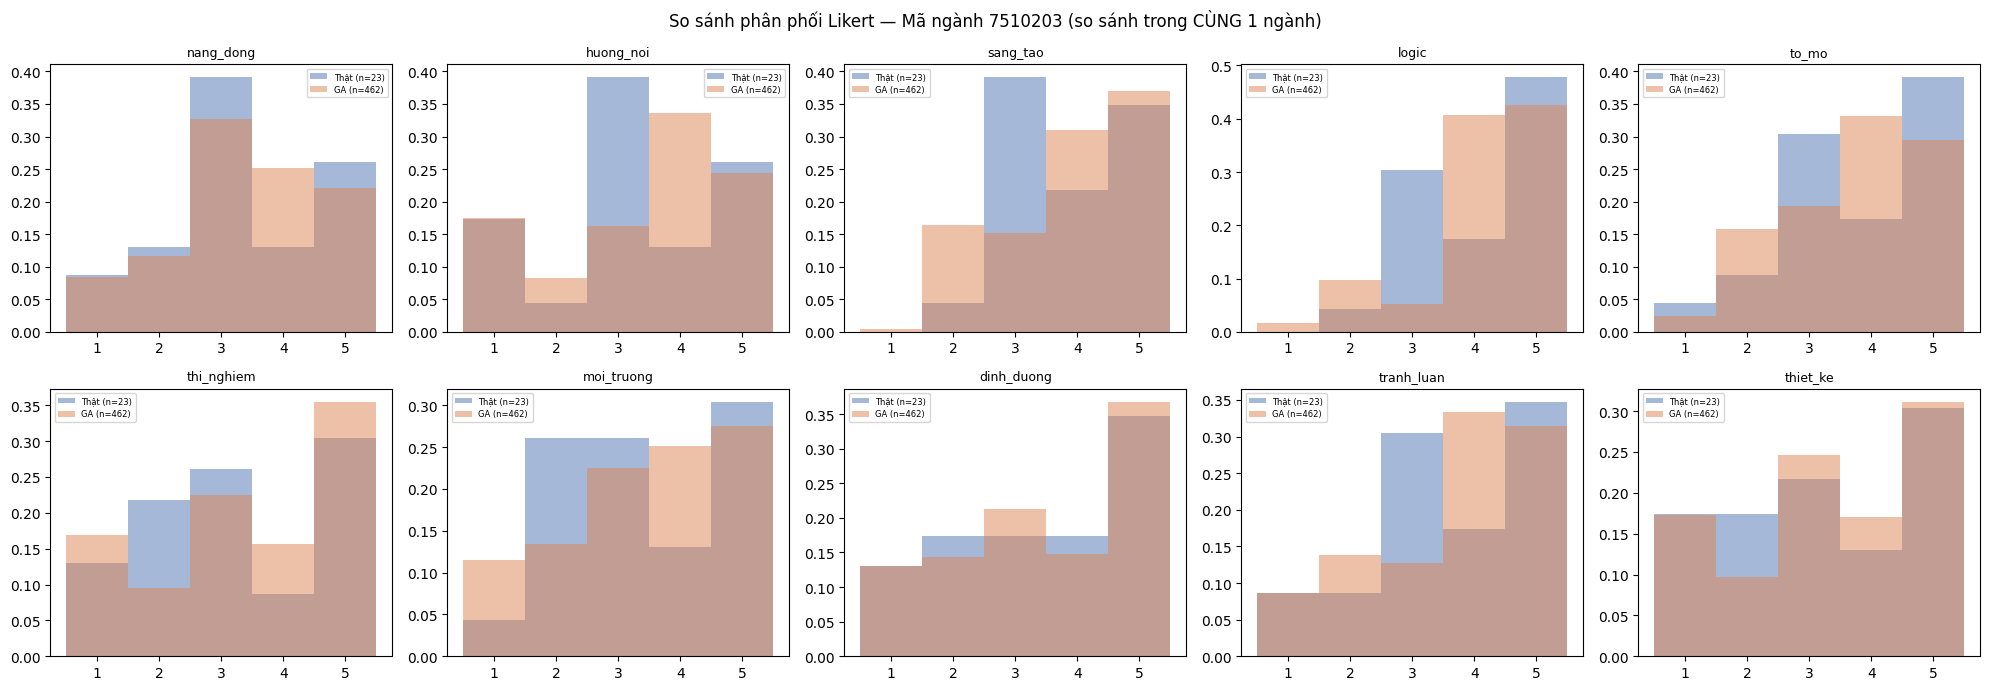

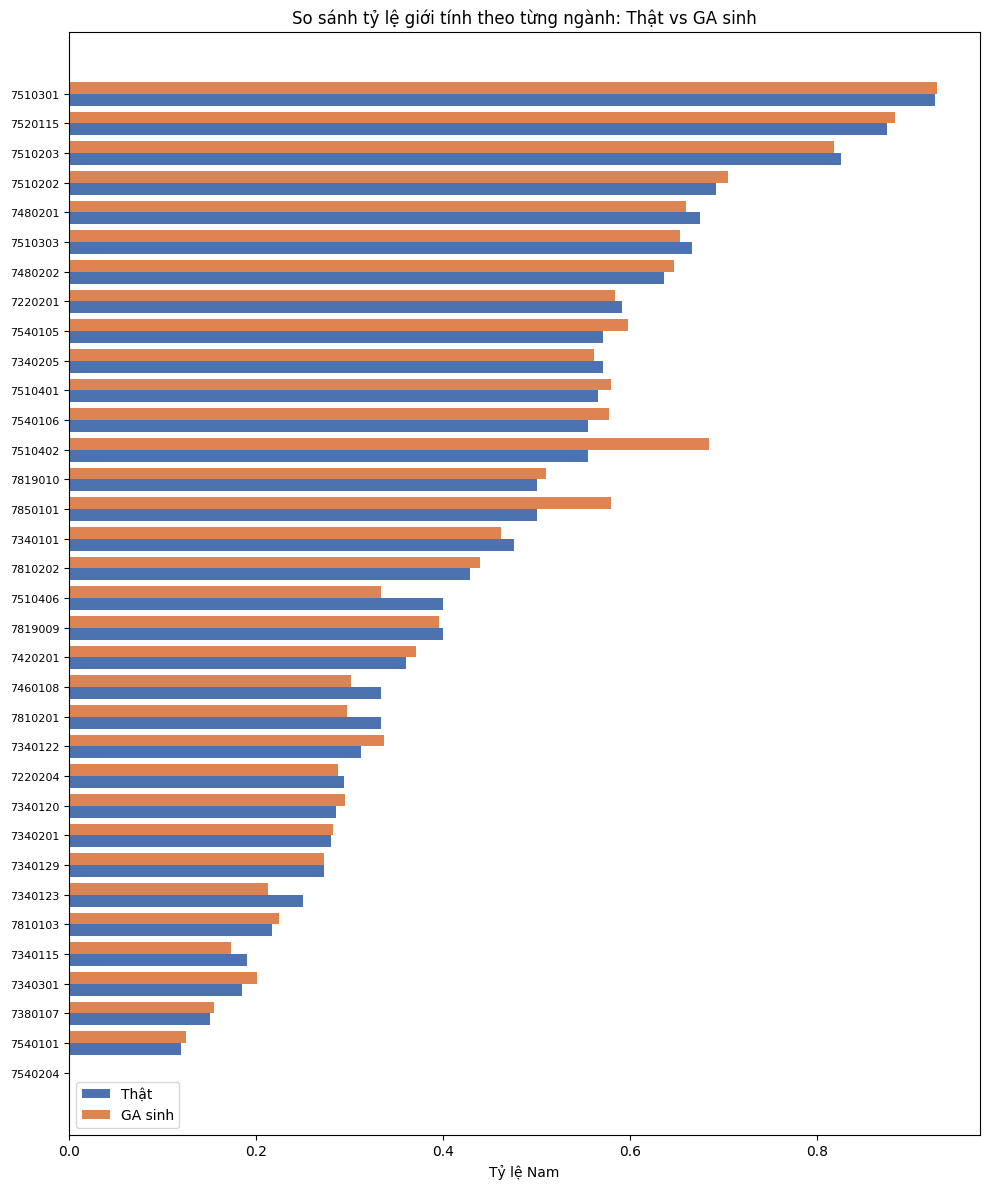

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

# ============================================================
# BIỂU ĐỒ 1 — giữ nguyên, không đổi (không liên quan lỗi pooling)
# ============================================================
so_dong_ttth = df_ttth_day_du['ma_nganh'].value_counts()
so_dong_khaosat = df_train_khaosat['ma_nganh'].value_counts()
so_dong_can_bang = df_can_bang['ma_nganh'].value_counts() if len(df_can_bang) > 0 else pd.Series(dtype=int)

tong_truoc_4b = so_dong_ttth.add(so_dong_khaosat, fill_value=0)
tong_sau_4b = tong_truoc_4b.add(so_dong_can_bang, fill_value=0)

compare = pd.DataFrame({
    'Trước cân bằng (khảo sát + TTTH)': tong_truoc_4b,
    'Sinh thêm (GA cân bằng lớp)': so_dong_can_bang
}).fillna(0).sort_values('Trước cân bằng (khảo sát + TTTH)')

fig, ax = plt.subplots(figsize=(10, 12))
compare.plot(kind='barh', stacked=True, ax=ax, color=['#4C72B0', '#55A868'])
ax.axvline(MUC_TIEU_MOI_NGANH, color='red', linestyle='--', linewidth=1,
           label=f'Mục tiêu ({MUC_TIEU_MOI_NGANH} dòng/ngành)')
ax.set_xlabel('Số dòng')
ax.set_title('Số dòng mỗi ngành trước và sau Giai đoạn 4B (Cân bằng lớp)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'bieu_do_4b_can_bang_lop.png', dpi=150)
plt.show()

# ============================================================
# BIỂU ĐỒ 2 — giữ nguyên, không đổi
# ============================================================
ty_le_lech_truoc = tong_truoc_4b.max() / tong_truoc_4b.min()
ty_le_lech_sau = tong_sau_4b.max() / tong_sau_4b.min()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Trước cân bằng', 'Sau cân bằng'], [ty_le_lech_truoc, ty_le_lech_sau],
       color=['#C44E52', '#55A868'])
ax.set_ylabel('Tỷ lệ lệch (ngành nhiều nhất / ngành ít nhất)')
ax.set_title('Mức độ cải thiện mất cân bằng lớp sau GA')
for i, v in enumerate([ty_le_lech_truoc, ty_le_lech_sau]):
    ax.text(i, v + 0.3, f'{v:.1f}x', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'bieu_do_ty_le_lech_can_bang.png', dpi=150)
plt.show()
print(f"Tỷ lệ lệch trước cân bằng: {ty_le_lech_truoc:.1f} lần")
print(f"Tỷ lệ lệch sau cân bằng: {ty_le_lech_sau:.1f} lần")


# ============================================================
# SỬA — KIỂM ĐỊNH KS THEO TỪNG NGÀNH (đúng cách, không gộp)
# ============================================================
print("\n=== KIỂM ĐỊNH KS THEO TỪNG NGÀNH (không gộp, tránh lỗi trộn tỷ trọng) ===\n")

ket_qua_kiem_dinh = []
for ma_nganh in sorted(df_train_khaosat['ma_nganh'].dropna().unique()):
    that = df_train_khaosat[df_train_khaosat['ma_nganh'] == ma_nganh]
    ga = df_ttth_day_du[df_ttth_day_du['ma_nganh'] == ma_nganh]

    if len(that) < 2 or len(ga) < 2:
        continue

    so_cot_lech = 0
    for c in likert_cols:
        _, p = ks_2samp(that[c].values, ga[c].values)
        if p < 0.05:
            so_cot_lech += 1

    ket_qua_kiem_dinh.append({
        'ma_nganh': int(ma_nganh),
        'so_mau_that': len(that),
        'so_mau_ga': len(ga),
        'so_cot_lech': so_cot_lech,
        'tong_cot': len(likert_cols),
    })

df_kq = pd.DataFrame(ket_qua_kiem_dinh).sort_values('so_cot_lech', ascending=False)
print(df_kq.to_string(index=False))
print(f"\nSố ngành có ít nhất 1/10 cột lệch: {(df_kq['so_cot_lech']>0).sum()} / {len(df_kq)}")
print(f"Số ngành hoàn toàn khớp (0 cột lệch): {(df_kq['so_cot_lech']==0).sum()} / {len(df_kq)}")

# Biểu đồ tổng hợp: tỷ lệ ngành đạt/lệch
fig, ax = plt.subplots(figsize=(6, 5))
dat = (df_kq['so_cot_lech'] == 0).sum()
lech = len(df_kq) - dat
ax.bar(['Khớp hoàn toàn\n(0 cột lệch)', 'Có ít nhất\n1 cột lệch'], [dat, lech],
       color=['#55A868', '#C44E52'])
ax.set_ylabel('Số ngành')
ax.set_title('Kết quả kiểm định KS theo từng ngành (đúng cách)')
for i, v in enumerate([dat, lech]):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'bieu_do_ks_theo_nganh.png', dpi=150)
plt.show()


# ============================================================
# SỬA — BIỂU ĐỒ 3: chọn 3 ngành đại diện (không gộp tất cả),
# minh họa trực quan việc GA khớp phân phối TỪNG NGÀNH
# ============================================================
# Chọn 3 ngành: 1 ngành nhiều mẫu thật, 1 ngành trung bình, 1 ngành có mean đặc biệt
nganh_minh_hoa = df_kq.nlargest(1, 'so_mau_that')['ma_nganh'].tolist() + \
                 df_kq.iloc[len(df_kq)//2:len(df_kq)//2+1]['ma_nganh'].tolist()

for ma in nganh_minh_hoa:
    that = df_train_khaosat[df_train_khaosat['ma_nganh'] == ma]
    ga = df_ttth_day_du[df_ttth_day_du['ma_nganh'] == ma]

    fig, axes = plt.subplots(2, 5, figsize=(20, 7))
    axes = axes.flatten()
    for i, c in enumerate(likert_cols):
        axes[i].hist(that[c].values, bins=np.arange(0.5,6.5,1), alpha=0.5,
                     label=f'Thật (n={len(that)})', color='#4C72B0', density=True)
        axes[i].hist(ga[c].values, bins=np.arange(0.5,6.5,1), alpha=0.5,
                     label=f'GA (n={len(ga)})', color='#DD8452', density=True)
        axes[i].set_title(c.replace('likert_',''), fontsize=9)
        axes[i].legend(fontsize=6)
    plt.suptitle(f'So sánh phân phối Likert — Mã ngành {int(ma)} (so sánh trong CÙNG 1 ngành)', fontsize=12)
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / f'bieu_do_kiem_chung_nganh_{int(ma)}.png', dpi=150)
    plt.show()


# ============================================================
# SỬA — BIỂU ĐỒ 4: so sánh giới tính THEO TỪNG NGÀNH, không gộp
# ============================================================
gioi_tinh_compare = []
for ma_nganh in sorted(df_train_khaosat['ma_nganh'].dropna().unique()):
    that = df_train_khaosat[df_train_khaosat['ma_nganh'] == ma_nganh]
    ga = df_ttth_day_du[df_ttth_day_du['ma_nganh'] == ma_nganh]
    if len(that) < 2 or len(ga) < 2:
        continue
    gioi_tinh_compare.append({
        'ma_nganh': int(ma_nganh),
        'ty_le_nam_that': (that['gioi_tinh'] == 'Nam').mean(),
        'ty_le_nam_ga': (ga['gioi_tinh'] == 'Nam').mean(),
    })

df_gt = pd.DataFrame(gioi_tinh_compare).sort_values('ty_le_nam_that')

fig, ax = plt.subplots(figsize=(10, 12))
y_pos = np.arange(len(df_gt))
ax.barh(y_pos - 0.2, df_gt['ty_le_nam_that'], height=0.4, label='Thật', color='#4C72B0')
ax.barh(y_pos + 0.2, df_gt['ty_le_nam_ga'], height=0.4, label='GA sinh', color='#DD8452')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_gt['ma_nganh'].astype(str), fontsize=8)
ax.set_xlabel('Tỷ lệ Nam')
ax.set_title('So sánh tỷ lệ giới tính theo từng ngành: Thật vs GA sinh')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'bieu_do_gioi_tinh_theo_nganh.png', dpi=150)
plt.show()

In [13]:
print("=== SO SÁNH MEAN/STD: GA vs THẬT (đo hiệu ứng thực tế, không phải p-value) ===\n")

for ma_nganh in [7480201, 7340301, 7819009]:  # 1 ngành lệch nhiều, 1 lệch nhiều, 1 khớp hoàn toàn
    that = df_train_khaosat[df_train_khaosat['ma_nganh'] == ma_nganh]
    ga = df_ttth_day_du[df_ttth_day_du['ma_nganh'] == ma_nganh]
    print(f"--- Ngành {ma_nganh} (that={len(that)}, ga={len(ga)}) ---")
    for c in likert_cols:
        m_that, s_that = that[c].mean(), that[c].std()
        m_ga, s_ga = ga[c].mean(), ga[c].std()
        print(f"  {c:20s}: Mean thật={m_that:.2f} vs GA={m_ga:.2f} (lệch {abs(m_that-m_ga):.2f})"
              f"  |  Std thật={s_that:.2f} vs GA={s_ga:.2f} (lệch {abs(s_that-s_ga):.2f})")
    print()

=== SO SÁNH MEAN/STD: GA vs THẬT (đo hiệu ứng thực tế, không phải p-value) ===

--- Ngành 7480201 (that=43, ga=1866) ---
  likert_nang_dong    : Mean thật=3.09 vs GA=2.99 (lệch 0.10)  |  Std thật=1.19 vs GA=1.11 (lệch 0.08)
  likert_huong_noi    : Mean thật=3.51 vs GA=3.62 (lệch 0.11)  |  Std thật=1.20 vs GA=1.26 (lệch 0.06)
  likert_sang_tao     : Mean thật=3.70 vs GA=3.68 (lệch 0.02)  |  Std thật=0.83 vs GA=0.89 (lệch 0.05)
  likert_logic        : Mean thật=3.79 vs GA=3.96 (lệch 0.17)  |  Std thật=0.89 vs GA=1.03 (lệch 0.14)
  likert_to_mo        : Mean thật=3.88 vs GA=3.87 (lệch 0.01)  |  Std thật=0.91 vs GA=0.96 (lệch 0.05)
  likert_thi_nghiem   : Mean thật=3.19 vs GA=3.22 (lệch 0.04)  |  Std thật=1.18 vs GA=1.19 (lệch 0.01)
  likert_moi_truong   : Mean thật=3.40 vs GA=3.41 (lệch 0.02)  |  Std thật=1.16 vs GA=1.17 (lệch 0.01)
  likert_dinh_duong   : Mean thật=3.47 vs GA=3.52 (lệch 0.06)  |  Std thật=1.18 vs GA=1.20 (lệch 0.01)
  likert_tranh_luan   : Mean thật=3.37 vs GA=3.36 (lệch